# Tutorial: Exact Diagonalization Model

Welcome to the **QPyD** tutorial for the Hamiltonian-based microscopic model. 

In this notebook, we will:
1. Define a quantum dot using single-particle orbital energies and Coulomb interactions.
2. Use the exact diagonalization engine to automatically generate the many-body states.
3. Inspect the analytical and numerical Hamiltonian.
4. Simulate the transport properties (Coulomb diamonds).

## 1. Imports
Let's import `numpy` and the three core classes of our package: the parameter factory, the simulator, and the plotter. We will also import `display` to cleanly render LaTeX math inside the notebook.

In [1]:
import numpy as np
from IPython.display import display
from qpyd import DerivedParameters, Simulator, Plotter

## 2. Setting Up the Microscopic Parameters

We first set the single-particle configuration and the charge sectors we want to resolve in the Quantum Dot. 

Here we assume a system with **two available single-particle orbitals**, each capable of hosting up to 2 electrons. We will enable electron-electron interactions by defining the intra-orbital ($U$), inter-orbital ($V$), and exchange ($J$) Coulomb matrix elements. 

For this simulation, we are interested in the transport window where the Quantum Dot transitions between $N=2$ and $N=3$ electrons.

In [2]:
# Feel free to experiment with different parameter values!

# 1. Single-Particle Energies (meV)
orbital_energies = [2.0, 2.6]  

# 2. Coulomb Interactions (meV)
U = 0.5 * np.ones(2)               # Intra-orbital Coulomb repulsion
J = 0.01 * np.ones((2, 2))         # Exchange interaction
np.fill_diagonal(J, 0)             # No exchange within the same orbital
V = J                              # Inter-orbital Coulomb (set equal to J here for simplicity)

# 3. Tunnel Couplings to Leads (meV)
# Format: [[Gamma_L_orb1, Gamma_R_orb1], [Gamma_L_orb2, Gamma_R_orb2]]
gammas = [[1.0, 1.0], [1.5, 1.5]]

# 4. External Fields
B = [0.0, 0.0, 0.0]                # Magnetic field vector (Tesla)

# 5. Initialize the Engine
params = DerivedParameters(
    charge_numbers=[2, 3],         # The charge transitions to simulate
    orbital_energies=orbital_energies,    
    T=0.2,                         # Temperature in K
    slopes=[1.0, 1.0],             # Slopes of Coulomb diamonds (automatically define the lever arms)
    U=U, V=V, J=J, Jp=J,           # Electron-electron interactions
    B=B,  
    gammas=gammas, 
    M_rel=0.0,                     # Phonon relaxation strength
    datapoints=200,                # Voltage grid resolution (200x200)
    setup="ground_R"               # Right lead is grounded
)

# Initialize the Simulator and Plotter tools
sim = Simulator(params)
plotter = Plotter()

### Reviewing the Configuration
The parameter object automatically calculates the necessary voltage windows and lever arms based on the energy scales we provided. However, it might be more convenient to specify our own ranges. This can easily be done by specifying the parameters `Vg_range` and `Vb_range` which take the form `[min_val, max_val, num_points]`.

 We can inspect these internal configurations easily:

In [3]:
params.params_config

{'Occupations & Level Spacing': {2: [2.0, 2.6], 3: [2.0, 2.6]},
 'Direct Intra-orbital Coulomb U': array([0.5, 0.5]),
 'Direct Inter-orbital Coulomb V': array([[0.  , 0.01],
        [0.01, 0.  ]]),
 'Exchange J': array([[0.  , 0.01],
        [0.01, 0.  ]]),
 'Pair-hopping Jp': array([[0.  , 0.01],
        [0.01, 0.  ]]),
 'Magnetic Field B [Bx, By, Bz]': [0.0, 0.0, 0.0],
 'Lead Tunnel Couplings [Γ_L, Γ_R]': [[1.0, 1.0], [1.5, 1.5]],
 'Relaxation Matrix Elements M_rel': array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]),
 'Coulomb Diamond Slopes [s1, s2]': [1.0, 1.0],
 'Lever Arms [a_L, a_R, a_G]': [0.5, 0.0, 0.5],
 'g factor': 2.0,
 'V_g range': [3.14, 7.34],
 'V_b range': [-1.5, 1.5],
 'Bias-voltage Setup': 'ground_R'}

## 3. Inspecting the Hamiltonian

One of the most powerful features of `DerivedParameters` is its ability to map physical inputs to symbolic and numerical Hamiltonian matrices. Let's take a look under the hood at the $N=2$ charge sector.

In [4]:
print("--- Symbolic Operator Hamiltonian ---")
display(params.symbolic_hamiltonian) 

# We will inspect the N=2 electron subspace
N_inspect = 2

# The method returns the numerical matrix, the basis list, and the symbolic equation
H_num, basis, H_sym = params.construct_hamiltonian(N_inspect)

print(f"\n--- Numerical Hamiltonian Matrix (N={N_inspect}) ---")
print(f"Matrix Shape: {H_num.shape}")
print(np.round(H_num, 3))

# Print the eigen-energies and eigenstates of the Hamiltonian
print(f"\n--- Eigen-energies and Eigenstates for N={N_inspect} ---")

for i, state_info in enumerate(params.states_dict[N_inspect]):
    try:
        # Extract the numerical energy and symbolic state from the dictionary
        energy = state_info['energy']
        eigenstate = state_info['eigenstate']
        
        # Print the energy and display the state
        print(f"State {i}: E = {energy:.4f} meV")
        display(eigenstate)
        
    except KeyError:
        # Silently pass if 'energy' or 'eigenstate' keys are missing
        pass

--- Symbolic Operator Hamiltonian ---


-0.01*c^\dagger_{0, \downarrow}*c_{0, \uparrow}*c^\dagger_{1, \uparrow}*c_{1, \downarrow} + 0.01*c^\dagger_{0, \uparrow}*c^\dagger_{0, \downarrow}*c_{1, \downarrow}*c_{1, \uparrow} - 0.01*c^\dagger_{0, \uparrow}*c_{0, \downarrow}*c^\dagger_{1, \downarrow}*c_{1, \uparrow} + 0.01*c^\dagger_{1, \uparrow}*c^\dagger_{1, \downarrow}*c_{0, \downarrow}*c_{0, \uparrow} + 0.5*n_{0, \uparrow}*n_{0, \downarrow} + 0.5*n_{1, \uparrow}*n_{1, \downarrow} - 0.005*(-n_{0, \downarrow} + n_{0, \uparrow})*(-n_{1, \downarrow} + n_{1, \uparrow}) + 2.0*(n_{0, \downarrow} + n_{0, \uparrow}) + 0.01*(n_{0, \downarrow} + n_{0, \uparrow})*(n_{1, \downarrow} + n_{1, \uparrow}) + 2.6*(n_{1, \downarrow} + n_{1, \uparrow})


--- Numerical Hamiltonian Matrix (N=2) ---
Matrix Shape: (6, 6)
[[ 4.5    0.     0.     0.     0.     0.01 ]
 [ 0.     4.605  0.     0.     0.     0.   ]
 [ 0.     0.     4.615 -0.01   0.     0.   ]
 [ 0.     0.    -0.01   4.615  0.     0.   ]
 [ 0.     0.     0.     0.     4.605  0.   ]
 [ 0.01   0.     0.     0.     0.     5.7  ]]

--- Eigen-energies and Eigenstates for N=2 ---
State 0: E = 4.4999 meV


'|2, 0.0, 0.0> = -|1, 1, 0, 0) + 0.008*|0, 0, 1, 1)'

State 1: E = 4.6050 meV


...

'|2, 1.0, 1.0> = -|1, 0, 1, 0)'

State 4: E = 4.6250 meV


'|2, 0.0, 0.0> = -0.707*|1, 0, 0, 1) + 0.707*|0, 1, 1, 0)'

State 5: E = 5.7001 meV


'|2, 0.0, 0.0> = -0.008*|1, 1, 0, 0) - |0, 0, 1, 1)'

## 4. Visualizing Specific Many-Body States

We can use the plotter to visualize the exact electron distribution and spin configuration for any generated state. Let's look at a specific excited state in the $N=2$ sector.

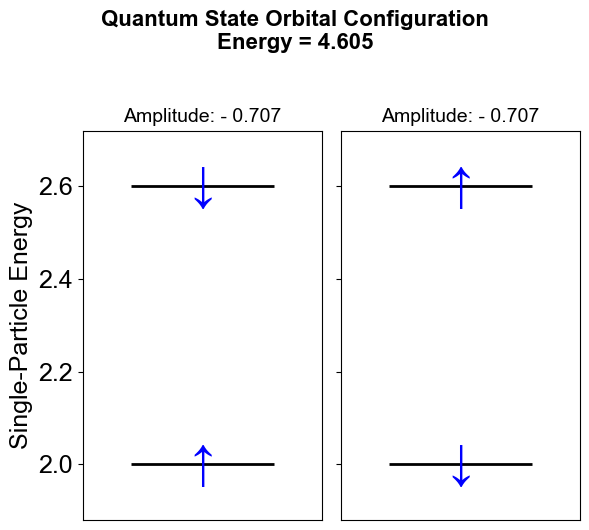

In [5]:
# Select a specific state from the dictionary: N=2, 3rd energy level (index 2)
N_target = 2 
state_index = 2

my_state = params.states_dict[N_target][state_index]

plotter.plot_spin_configuration(
    orbital_energies=params.orbital_energies, 
    state_dict=my_state
)

## 5. Simulating Charge Transport

Now that the physical system is fully constructed, we pass the parameters to the JAX backend. 

The solver will stream data to the CPU in batches (chunking) to ensure that high-resolution grids do not exceed your GPU's VRAM limits.

Starting solver (Total points: 4.00e+04, Total parameters: 4.00e+05)...
Solved full grid in 0.58s.


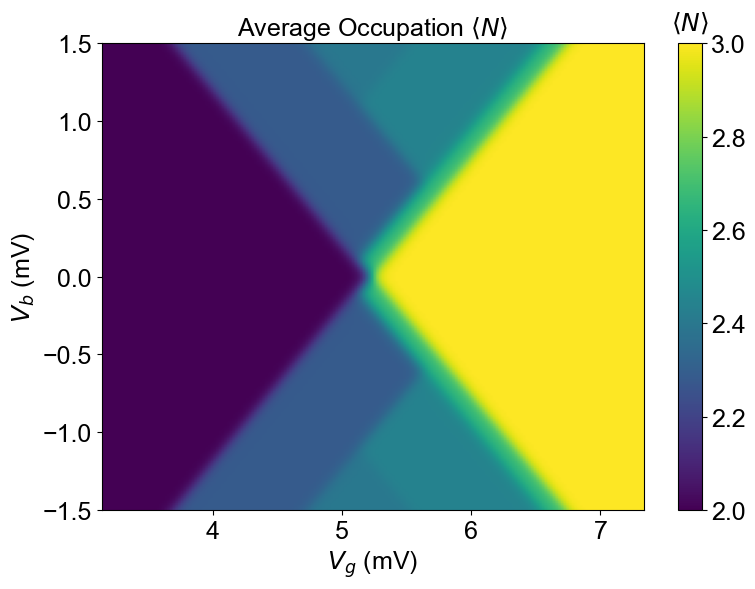

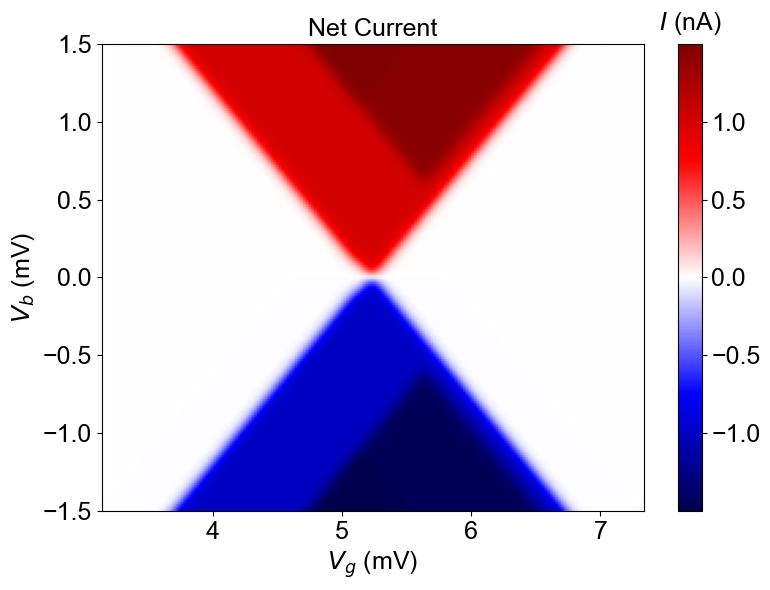

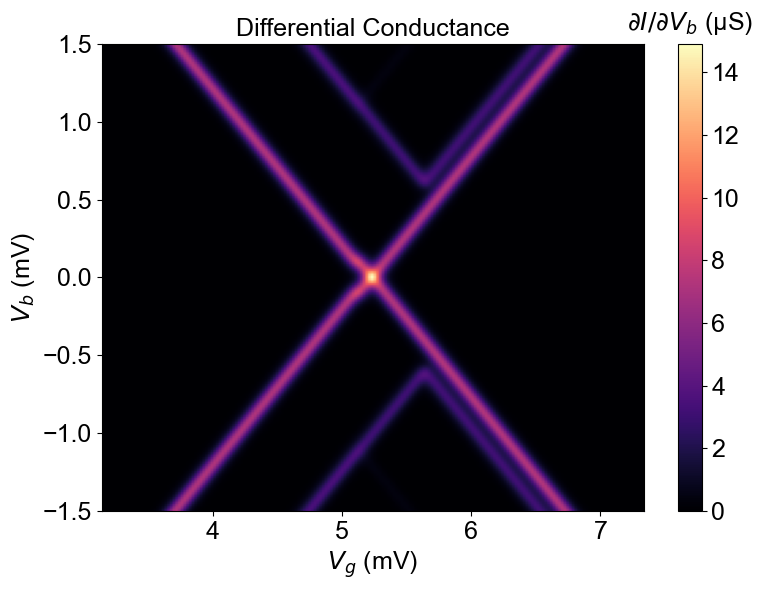

<Axes: title={'center': '$V_b \\approx 1.003$ mV'}, xlabel='$V_g$ (mV)', ylabel='$\\partial I / \\partial V_b$ (μS)'>

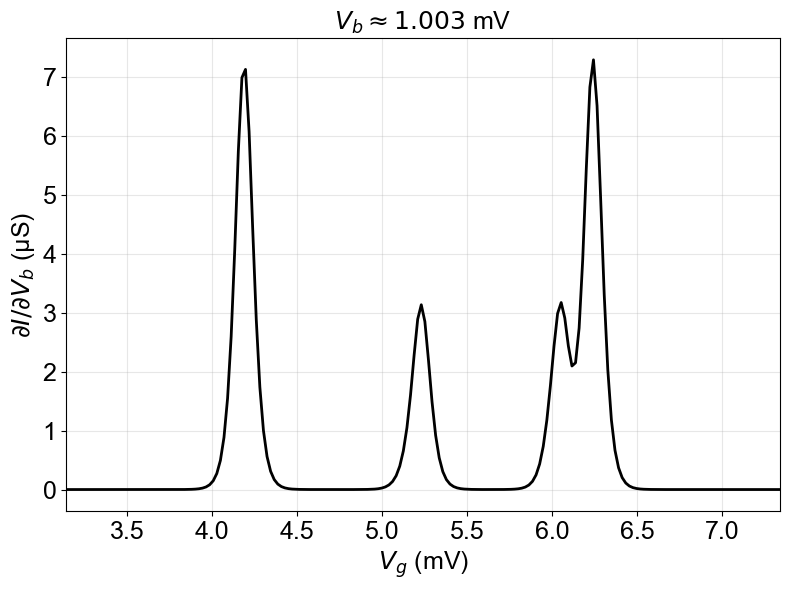

In [6]:
# Solve the master equation across the 300x300 grid
sim.solve(batch_size=1000)

# Pull the evaluated arrays back from JAX memory
results = sim.get_results()

# Define the physical axes limits for the plot
extent = [params.Vgmin, params.Vgmax, params.Vbmin, params.Vbmax]

# Define the axes units and the units of the quantities to be plotted
axes_units = ['mV', 'mV']
curr_unit = 'nA'
conductance_unit = 'μS'

# 1. Plot the Average Charge Occupation
plotter.plot_map(results=results, 
                 quantity='N_avg', 
                 extent=extent, 
                 title="Average Occupation $\\langle N \\rangle$",
                 axes_units=axes_units
                 )

# 2. Plot the DC Current
plotter.plot_map(results=results, 
                 quantity='I', 
                 extent=extent, 
                 title="Net Current",
                 axes_units=axes_units,
                 quantity_units=curr_unit)

# 3. Plot the Differential Conductance
plotter.plot_map(results=results, 
                 quantity='G', 
                 extent=extent, 
                 title="Differential Conductance",
                 axes_units=axes_units,
                 quantity_units=conductance_unit)

# 4. Plot a slice at a constant bias
plotter.plot_slice(results=results, 
                   quantity='G', 
                   fixed_value=1.0,
                   cut_type='horizontal',
                   axes_units=axes_units,
                   quantity_units=conductance_unit
                   )

## 6. Exploring the Full State Dictionary

All calculated eigenvalues, transition rates, spin properties, and quantum numbers are stored in `params.states_dict`. This is highly useful for debugging or passing physical properties into custom downstream scripts.

In [7]:
# Warning: This prints a lot of data!
params.states_dict

{2: [{'eigenstate': '|2, 0.0, 0.0> = -|1, 1, 0, 0) + 0.008*|0, 0, 1, 1)',
   'single_particle_kets': [(-1, '|1, 1, 0, 0)', array([1, 1, 0, 0])),
    (np.float64(0.008), '|0, 0, 1, 1)', array([0, 0, 1, 1]))],
   'energy': np.float64(4.49992),
   'S': np.float64(0.0),
   'Sz': np.float64(0.0)},
  {'eigenstate': '|2, 1.0, -1.0> = |0, 1, 0, 1)',
   'single_particle_kets': [(1, '|0, 1, 0, 1)', array([0, 1, 0, 1]))],
   'energy': np.float64(4.605),
   'S': np.float64(1.0),
   'Sz': np.float64(-1.0)},
  {'eigenstate': '|2, 1.0, 0.0> = -0.707*|1, 0, 0, 1) - 0.707*|0, 1, 1, 0)',
   'single_particle_kets': [(np.float64(-0.707),
     '|1, 0, 0, 1)',
     array([1, 0, 0, 1])),
    (np.float64(-0.707), '|0, 1, 1, 0)', array([0, 1, 1, 0]))],
   'energy': np.float64(4.605),
   'S': np.float64(1.0),
   'Sz': np.float64(0.0)},
  {'eigenstate': '|2, 1.0, 1.0> = -|1, 0, 1, 0)',
   'single_particle_kets': [(-1, '|1, 0, 1, 0)', array([1, 0, 1, 0]))],
   'energy': np.float64(4.605),
   'S': np.float64(1.0),